<a href="https://colab.research.google.com/github/asiddiqha/smartcart-customer-segmentation/blob/main/SmartCart_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartCart Customer Segmentation

### From customer data to actionable marketing segments

**Objective:** Use unsupervised machine learning to identify meaningful customer segments from purchasing behaviour, engagement, loyalty, and demographic indicators.

> **Business framing:** SmartCart has 2,240 customer records and 22 attributes covering demographics, purchase behaviour, website activity, recency, complaints, and campaign response. The goal is to move beyond generic marketing toward data-driven customer segmentation and retention.

## Executive Summary

This project builds an end-to-end customer segmentation pipeline:

**Data quality → Feature engineering → Exploratory analysis → Outlier handling → Encoding & scaling → PCA → K selection → K-Means clustering → Cluster profiling → Business recommendations**

A key modeling decision is to **exclude `Response` and `Complain` from the clustering features**. They are retained for post-clustering profiling so that the resulting segments are not artificially defined by campaign response or complaint status.

The final segmentation uses **K-Means with K=4** as a business-friendly segmentation choice. Cluster quality is evaluated using silhouette score and Davies–Bouldin score rather than relying on the elbow curve alone.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

## 1. Load the Dataset

Each row represents a SmartCart customer. The dataset contains **2,240 records and 22 original attributes**.

In [2]:
df = pd.read_csv("smartcart_customers.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Rows: 2,240
Columns: 22


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0


## 2. Data Quality Audit

Before modeling, inspect:

- missing values
- duplicate records
- data types
- numerical ranges
- categorical distributions
- suspicious values/outliers

This is important because K-Means is distance-based and therefore sensitive to scale and extreme observations.

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique()
}).sort_values(["missing", "unique"], ascending=[False, True])

display(quality)

print("Duplicate rows:", df.duplicated().sum())

,dtype,missing,missing_%,unique
Income,float64,24,1.07,1974
Complain,int64,0,0.00,2
Response,int64,0,0.00,2
Kidhome,int64,0,0.00,3
Teenhome,int64,0,0.00,3
Education,object,0,0.00,5
Marital_Status,object,0,0.00,8
NumCatalogPurchases,int64,0,0.00,14
NumStorePurchases,int64,0,0.00,14
NumDealsPurchases,int64,0,0.00,15


Duplicate rows: 0


In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


### Initial observations

The dataset contains **24 missing `Income` values**. Income also contains a very large upper-end value, so it is important to handle missing income and extreme observations before distance-based clustering.

## 3. Feature Engineering

The raw columns are transformed into business-oriented variables.

### Engineered features

- **Age** — derived from year of birth
- **Customer_Tenure_Days** — time since customer enrollment relative to the latest enrollment date
- **Total_Spending** — total amount spent across all product categories
- **Total_Purchases** — purchases across web, catalog, and store channels
- **Total_Children** — children + teenagers in the household
- **Living_With** — simplified household status
- **Education** — grouped into broader education levels

These features make the clusters easier to interpret from a customer-business perspective.

In [5]:
data = df.copy()

# Missing-value treatment
data["Income"] = data["Income"].fillna(data["Income"].median())

# Date conversion and tenure
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
reference_date = data["Dt_Customer"].max()
data["Customer_Tenure_Days"] = (reference_date - data["Dt_Customer"]).dt.days

# Demographic features
data["Age"] = 2026 - data["Year_Birth"]
data["Total_Children"] = data["Kidhome"] + data["Teenhome"]

# Spending and purchase features
spending_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]
purchase_cols = [
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"
]

data["Total_Spending"] = data[spending_cols].sum(axis=1)
data["Total_Purchases"] = data[purchase_cols].sum(axis=1)

# Simplify categorical variables
data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

data["Living_With"] = data["Marital_Status"].replace({
    "Together": "Partner",
    "Married": "Partner",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

display(data[[
    "Age", "Income", "Customer_Tenure_Days",
    "Total_Spending", "Total_Purchases", "Total_Children",
    "Education", "Living_With"
]].head())

,Age,Income,Customer_Tenure_Days,Total_Spending,Total_Purchases,Total_Children,Education,Living_With
0,69,58138.0,663,1617,22,0,Graduate,Single
1,72,46344.0,113,27,4,2,Graduate,Single
2,61,71613.0,312,776,20,0,Graduate,Partner
3,42,26646.0,139,53,6,1,Graduate,Partner
4,45,58293.0,161,422,14,1,Postgraduate,Partner


## 4. Exploratory Data Analysis

### Spending distribution

Total spending is a useful first indicator of customer value. We also compare income with spending because high income does not automatically imply high engagement or high customer value.

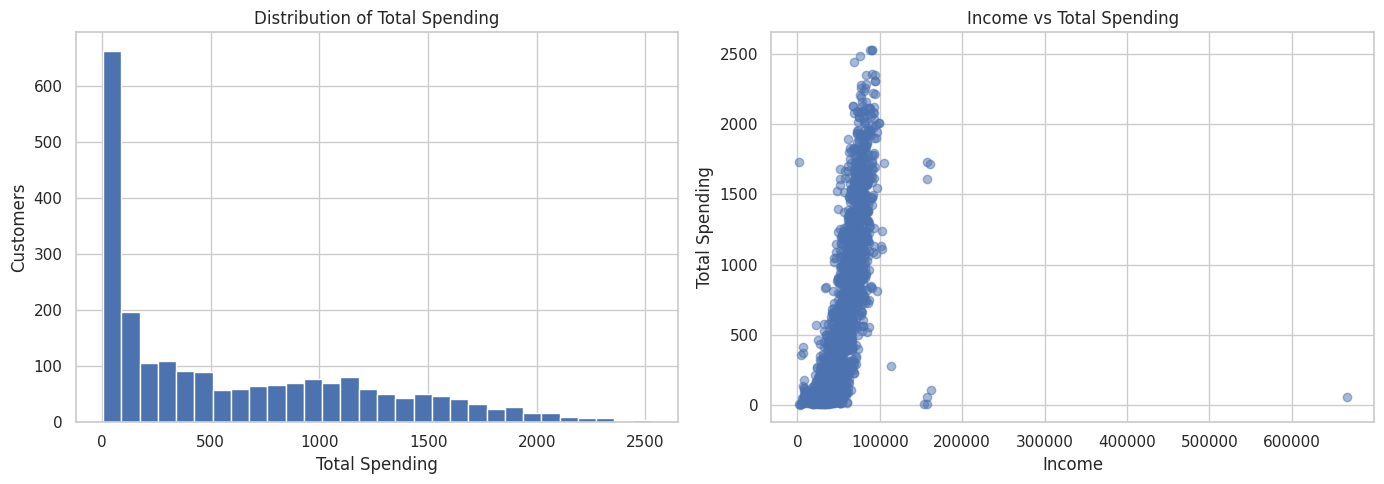

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data["Total_Spending"], bins=30)
axes[0].set_title("Distribution of Total Spending")
axes[0].set_xlabel("Total Spending")
axes[0].set_ylabel("Customers")

axes[1].scatter(
    data["Income"],
    data["Total_Spending"],
    alpha=0.5
)
axes[1].set_title("Income vs Total Spending")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Total Spending")

plt.tight_layout()
plt.show()

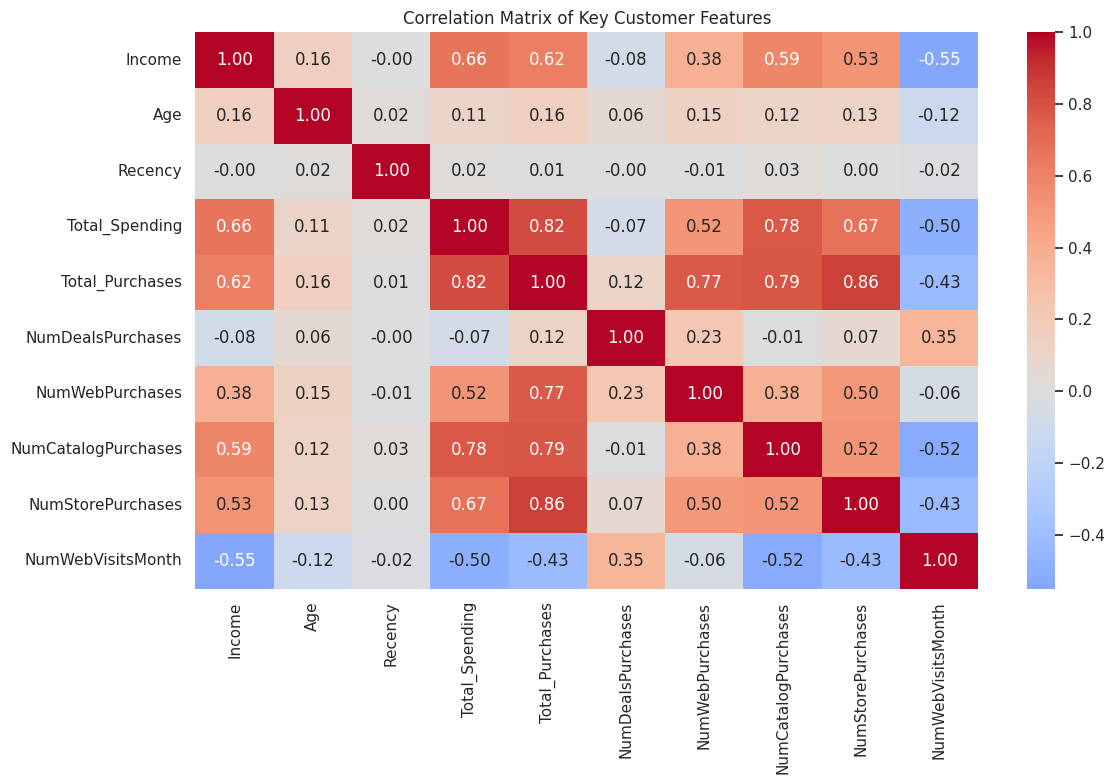

In [7]:
eda_cols = [
    "Income", "Age", "Recency", "Total_Spending",
    "Total_Purchases", "NumDealsPurchases",
    "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumWebVisitsMonth"
]

plt.figure(figsize=(12, 8))
sns.heatmap(
    data[eda_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Key Customer Features")
plt.tight_layout()
plt.show()

### How to read this analysis

For segmentation, the goal is not simply to maximize one metric. We want combinations such as:

- high spending + high purchase frequency
- frequent website visits + low purchases
- discount-heavy behaviour
- recent vs inactive customers
- differences in income and household characteristics

These combinations are what make the eventual clusters actionable.

## 5. Outlier Handling

K-Means uses Euclidean distance. A small number of extreme observations can therefore dominate centroid placement.

For this dataset we remove:

- customers with `Income >= 600,000`
- customers with `Age >= 90`

This is a modeling decision rather than a claim that those customers are invalid in the real world.

In [8]:
before = len(data)

data = data[
    (data["Income"] < 600000) &
    (data["Age"] < 90)
].copy()

after = len(data)

print(f"Customers before filtering: {before:,}")
print(f"Customers after filtering:  {after:,}")
print(f"Rows removed:               {before - after:,}")

Customers before filtering: 2,240
Customers after filtering:  2,236
Rows removed:               4


## 6. Define the Clustering Features

### Important modeling choice

`Response` and `Complain` are **not used to create the clusters**.

Why?

- `Response` represents campaign response and is better treated as an outcome/profile variable.
- `Complain` is extremely imbalanced and can create tiny clusters driven mainly by a binary flag.

Instead, both variables will be used later to answer a more useful business question:

> **Do the naturally discovered customer segments behave differently in terms of campaign response and complaints?**

In [9]:
numeric_features = [
    "Income",
    "Age",
    "Customer_Tenure_Days",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Total_Children",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

categorical_features = ["Education", "Living_With"]

cluster_numeric = data[numeric_features].copy()

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded = encoder.fit_transform(data[categorical_features])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=data.index
)

X = pd.concat([cluster_numeric, encoded_df], axis=1)

print("Clustering feature matrix:", X.shape)
display(X.head())

Clustering feature matrix: (2236, 18)


,Income,Age,Customer_Tenure_Days,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Total_Children,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Living_With_Single
0,58138.0,69,663,58,1617,22,3,7,0,8,10,4,1.0,0.0,0.0,0.0,0.0,1.0
1,46344.0,72,113,38,27,4,2,5,2,1,1,2,1.0,0.0,0.0,0.0,0.0,1.0
2,71613.0,61,312,26,776,20,1,4,0,8,2,10,1.0,0.0,0.0,0.0,1.0,0.0
3,26646.0,42,139,26,53,6,2,6,1,2,0,4,1.0,0.0,0.0,0.0,1.0,0.0
4,58293.0,45,161,94,422,14,5,5,1,5,3,6,0.0,1.0,0.0,0.0,1.0,0.0


## 7. Scale the Features

K-Means is distance-based. Without scaling, variables such as income or spending could dominate variables such as purchase counts.

StandardScaler transforms the numerical feature space so that features are comparable in magnitude.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (2236, 18)


## 8. PCA for Visualization

PCA is **not used to define the clusters** in this project.

It is used to project the high-dimensional customer feature space into 2D and 3D so we can visually inspect how the clusters are distributed.

We use **3 components** because the final visualization is intentionally 3D.

In [11]:
pca = PCA(n_components=3, random_state=42)
principal_components = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance:")
for i, ratio in enumerate(explained_variance, start=1):
    print(f"PC{i}: {ratio:.2%}")

print(f"Total variance explained by PC1-PC3: {explained_variance.sum():.2%}")

Explained variance:
PC1: 27.63%
PC2: 10.77%
PC3: 10.11%
Total variance explained by PC1-PC3: 48.52%


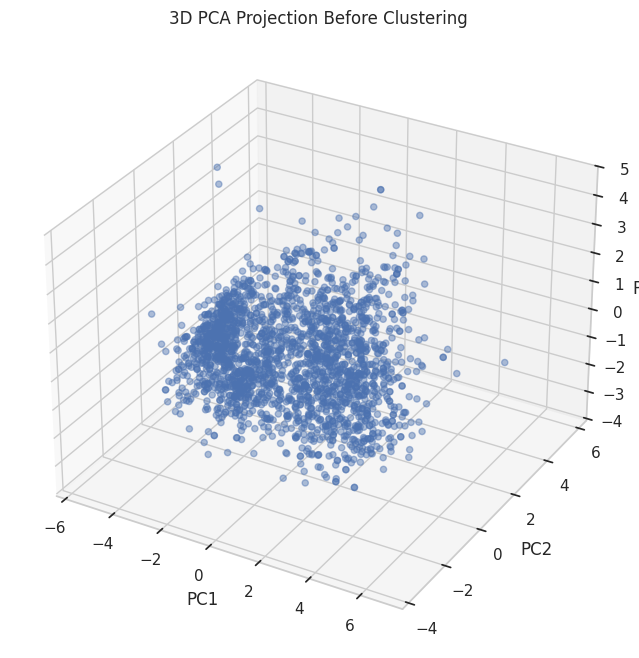

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    principal_components[:, 2],
    alpha=0.45
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection Before Clustering")

plt.show()

## 9. Choose the Number of Clusters

We evaluate several candidate values of K using:

1. **Elbow / WCSS** — measures within-cluster compactness.
2. **Silhouette score** — higher generally indicates better separation and cohesion.
3. **Davies–Bouldin index** — lower is better.
4. **Calinski–Harabasz score** — higher is generally better.

No single metric should be treated as the absolute truth. The final K should also produce segments that are large enough and interpretable for business use.

In [13]:
k_values = range(2, 11)

wcss = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42
    )
    labels = model.fit_predict(X_scaled)

    wcss.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    "K": list(k_values),
    "WCSS": wcss,
    "Silhouette": silhouette_scores,
    "Davies_Bouldin": db_scores,
    "Calinski_Harabasz": ch_scores
})

display(metrics_df.round(4))

,K,WCSS,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,31363.7027,0.2084,1.8273,632.8181
1,3,28925.8517,0.1554,2.2211,437.0229
2,4,26990.5961,0.1395,2.2721,365.4424
3,5,25183.4783,0.1529,2.0587,333.6408
4,6,23861.4336,0.1750,1.9314,306.2854
5,7,22472.6592,0.1684,1.8566,293.8477
6,8,21349.7805,0.1691,1.7713,281.7375
7,9,20443.3057,0.1683,1.7583,269.6791
8,10,19421.8896,0.1734,1.6873,265.2158


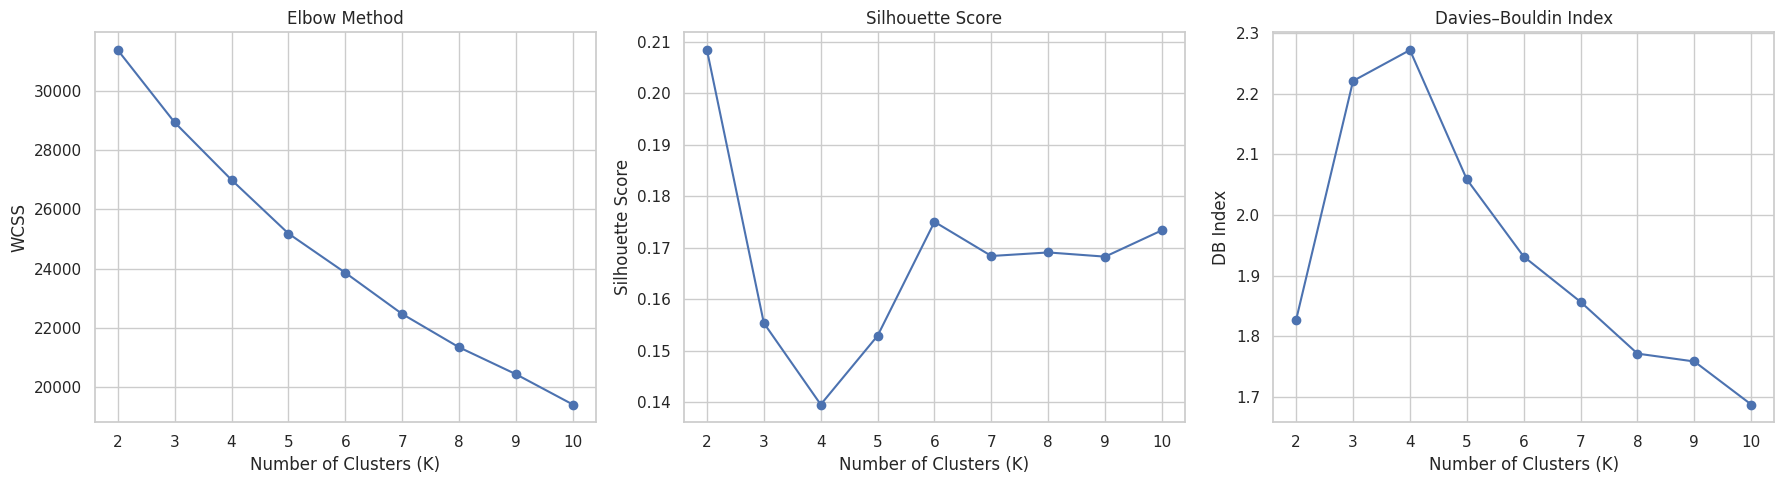

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_values, wcss, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

axes[2].plot(k_values, db_scores, marker="o")
axes[2].set_title("Davies–Bouldin Index")
axes[2].set_xlabel("Number of Clusters (K)")
axes[2].set_ylabel("DB Index")

plt.tight_layout()
plt.show()

### K selection

For this project, **K=4** is retained as the final business segmentation choice because it provides four interpretable customer groups and avoids turning the segmentation into an excessively granular taxonomy.

The validation metrics are deliberately reported rather than hidden: the clusters are useful for segmentation, but the separation is not perfect. This is an important modeling caveat to communicate in an interview or portfolio review.

## 10. Final K-Means Model

K-Means++ is used for centroid initialization and `n_init=20` is used to reduce dependence on a single initialization.

In [15]:
FINAL_K = 4

kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=20,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

data["Cluster"] = kmeans_labels

final_silhouette = silhouette_score(X_scaled, kmeans_labels)
final_db = davies_bouldin_score(X_scaled, kmeans_labels)
final_ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"Silhouette Score:       {final_silhouette:.4f}")
print(f"Davies–Bouldin Index:   {final_db:.4f}")
print(f"Calinski–Harabasz:      {final_ch:.2f}")

Silhouette Score:       0.1395
Davies–Bouldin Index:   2.2721
Calinski–Harabasz:      365.44


## 11. 3D Visualization of the Customer Segments

The PCA coordinates are only for visualization. The colours represent the K-Means labels generated from the original scaled feature space.

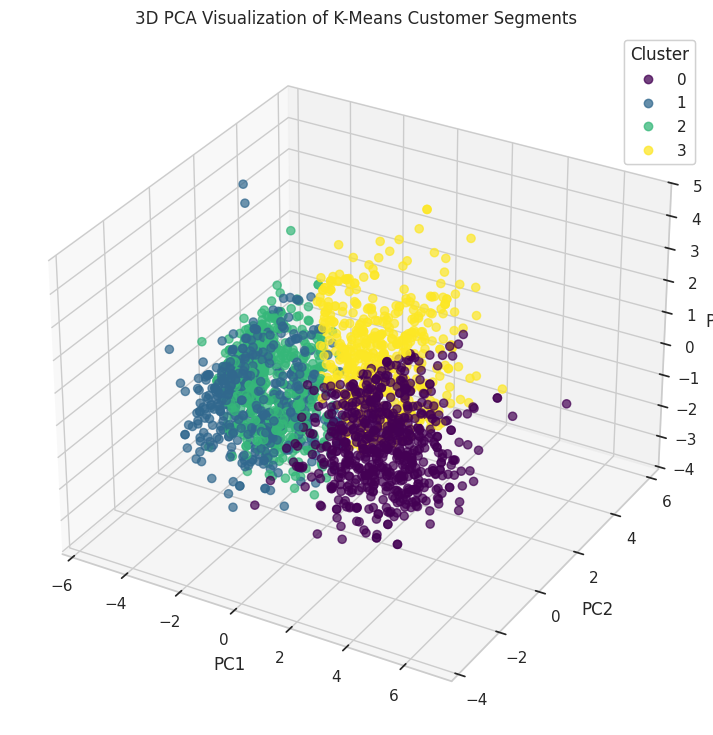

In [16]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    principal_components[:, 2],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.70,
    s=35
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Visualization of K-Means Customer Segments")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Cluster",
    loc="upper right"
)
ax.add_artist(legend)

plt.show()

## 12. Cluster Size

A segmentation is only useful operationally if each group is large enough to act on. We therefore inspect the customer count and percentage of the population in each cluster.

In [17]:
cluster_size = (
    data["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

cluster_size["Share_%"] = (
    cluster_size["Customers"] / len(data) * 100
).round(2)

display(cluster_size)

,Customers,Share_%
Cluster,,
0,638,28.53
1,403,18.02
2,670,29.96
3,525,23.48


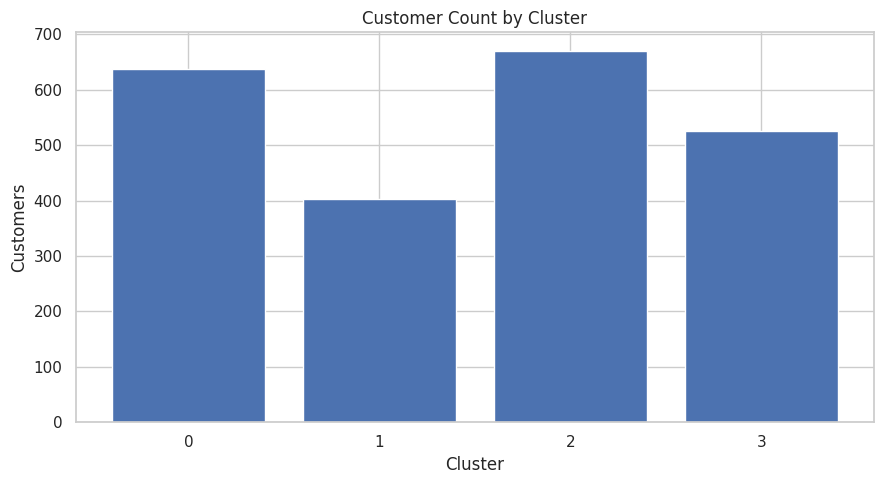

In [18]:
plt.figure(figsize=(9, 5))
counts = cluster_size["Customers"].values
labels = cluster_size.index.astype(str).values
plt.bar(labels, counts)
plt.title("Customer Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## 13. Cluster Profiling

The most important step is converting numeric cluster labels into **customer stories**.

We compare income, spending, purchase frequency, recency, website activity, discount usage, and campaign response.

In [19]:
profile_features = [
    "Income",
    "Age",
    "Customer_Tenure_Days",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Total_Children",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Response",
    "Complain"
]

cluster_profile = data.groupby("Cluster")[profile_features].mean()

display(cluster_profile.round(2))

,Income,Age,Customer_Tenure_Days,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Total_Children,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Response,Complain
Cluster,,,,,,,,,,,,,,
0,75449.50,58.20,334.56,49.26,1304.63,19.36,1.28,2.76,0.24,5.08,5.84,8.45,0.26,0.01
1,36150.75,54.80,327.07,49.26,129.67,6.48,2.19,6.43,1.23,2.34,0.74,3.40,0.13,0.01
2,35021.23,54.60,319.01,49.26,101.27,5.87,1.92,6.37,1.22,2.06,0.54,3.27,0.06,0.01
3,57135.79,60.73,441.98,48.65,766.72,17.44,4.23,6.23,1.26,6.82,2.98,7.63,0.14,0.01


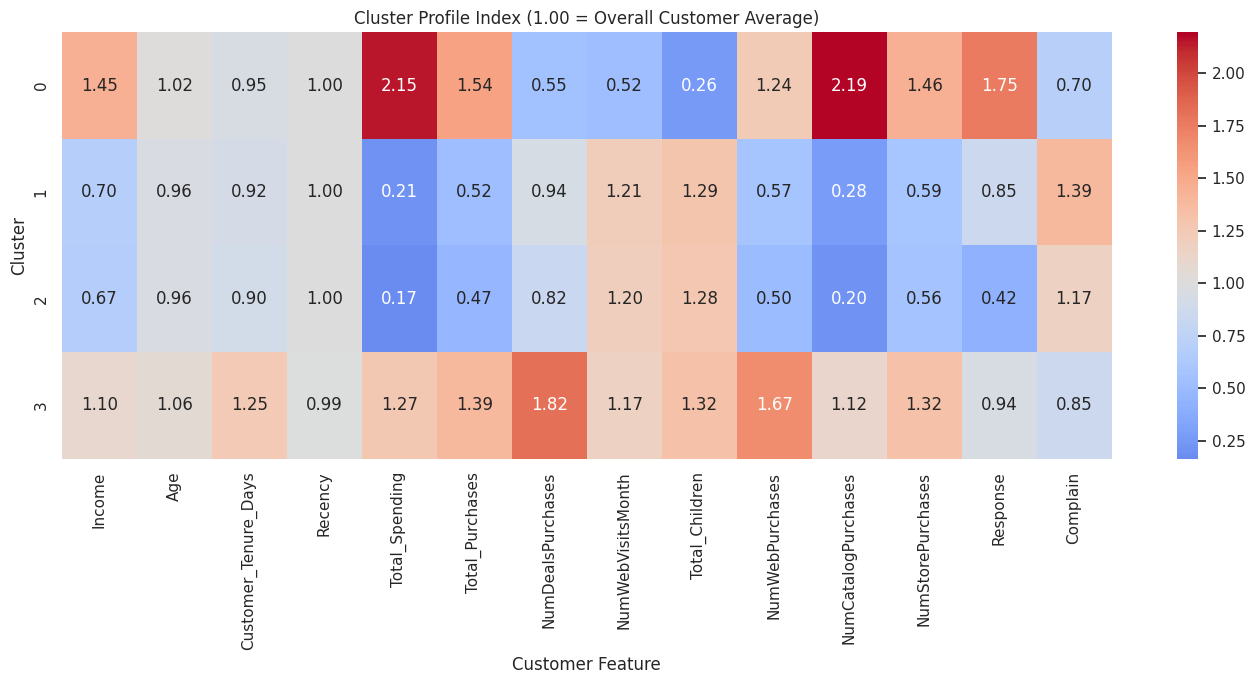

In [20]:
# Normalized profile: each cluster is compared with the overall customer average.
overall_mean = data[profile_features].mean()
profile_index = (cluster_profile / overall_mean).replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(14, 7))
sns.heatmap(
    profile_index,
    cmap="coolwarm",
    center=1,
    annot=True,
    fmt=".2f"
)
plt.title("Cluster Profile Index (1.00 = Overall Customer Average)")
plt.xlabel("Customer Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### How to interpret the profile heatmap

- **Above 1.00** → the cluster is above the overall customer average.
- **Below 1.00** → the cluster is below the overall customer average.
- This makes the cluster differences easier to explain than raw values alone.

Remember that the numeric cluster IDs (`0–3`) have no inherent business meaning. The labels below are assigned only after examining the profiles.

## 14. Business Segment Interpretation

The following labels are **interpretations of the observed cluster profiles**, not model outputs.

| Segment | Behavioural story | Suggested action |
|---|---|---|
| High-Value VIPs | Highest income and spending, strong purchase frequency and strongest campaign response | Retention, premium offers, loyalty benefits, cross-sell |
| Loyal Deal-Oriented Customers | Strong purchase activity, meaningful spending and relatively high discount usage | Targeted promotions, bundles, loyalty rewards |
| Developing / Price-Sensitive Customers | Lower income and spending, fewer purchases, but meaningful digital activity | Entry-level offers, personalized recommendations, conversion campaigns |
| Low-Engagement Customers | Lowest spending and purchase activity; comparatively weak response | Re-engagement, personalized reminders, low-cost offers; monitor churn risk |

The exact cluster-to-segment mapping is generated below from the observed profile values.

In [21]:
# Create a business-readable summary from the observed profiles.
summary = data.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Avg_Income=("Income", "mean"),
    Avg_Spending=("Total_Spending", "mean"),
    Avg_Purchases=("Total_Purchases", "mean"),
    Avg_Web_Visits=("NumWebVisitsMonth", "mean"),
    Avg_Deals=("NumDealsPurchases", "mean"),
    Avg_Recency=("Recency", "mean"),
    Campaign_Response=("Response", "mean")
).round(2)

summary["Customer_Share_%"] = (
    summary["Customers"] / len(data) * 100
).round(2)

display(summary.sort_values("Avg_Spending", ascending=False))

,Customers,Avg_Income,Avg_Spending,Avg_Purchases,Avg_Web_Visits,Avg_Deals,Avg_Recency,Campaign_Response,Customer_Share_%
Cluster,,,,,,,,,
0,638,75449.50,1304.63,19.36,2.76,1.28,49.26,0.26,28.53
3,525,57135.79,766.72,17.44,6.23,4.23,48.65,0.14,23.48
1,403,36150.75,129.67,6.48,6.43,2.19,49.26,0.13,18.02
2,670,35021.23,101.27,5.87,6.37,1.92,49.26,0.06,29.96


## 15. Campaign Response as an External Validation Signal

`Response` was deliberately excluded from clustering. Now we can check whether the naturally discovered behavioural segments have different campaign response rates.

This is more informative than using `Response` as a clustering input because it lets us ask whether **behavioural segmentation predicts marketing outcomes**.

In [22]:
response_profile = data.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Response_Rate=("Response", "mean"),
    Complaint_Rate=("Complain", "mean"),
    Avg_Recency=("Recency", "mean"),
    Avg_Spending=("Total_Spending", "mean")
)

response_profile["Response_Rate"] *= 100
response_profile["Complaint_Rate"] *= 100

display(response_profile.round(2))

,Customers,Response_Rate,Complaint_Rate,Avg_Recency,Avg_Spending
Cluster,,,,,
0,638,26.18,0.63,49.26,1304.63
1,403,12.66,1.24,49.26,129.67
2,670,6.27,1.04,49.26,101.27
3,525,14.10,0.76,48.65,766.72


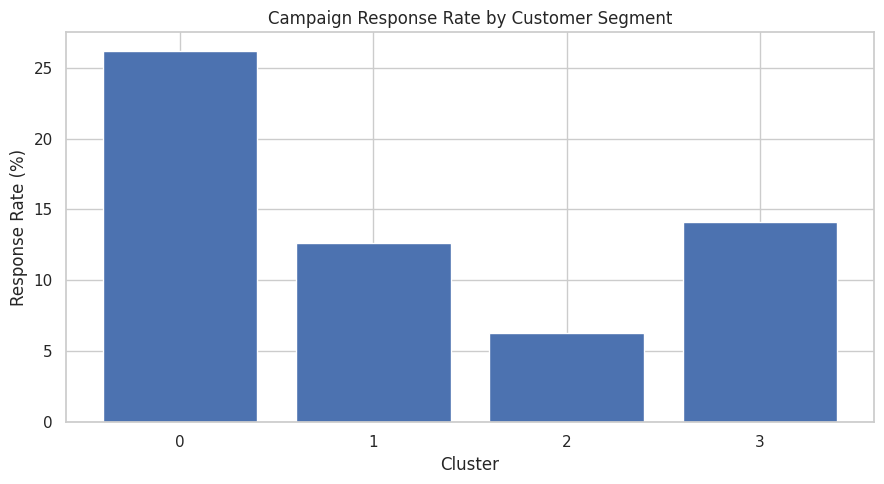

In [23]:
plt.figure(figsize=(9, 5))
rp = response_profile.reset_index()
plt.bar(rp["Cluster"].astype(str), rp["Response_Rate"])
plt.title("Campaign Response Rate by Customer Segment")
plt.xlabel("Cluster")
plt.ylabel("Response Rate (%)")
plt.tight_layout()
plt.show()

## 16. Agglomerative Clustering Comparison

A second unsupervised algorithm is useful as a robustness check.

We compare K-Means with Ward-linkage Agglomerative Clustering using the same scaled feature matrix and the same K=4.

In [24]:
agglomerative = AgglomerativeClustering(
    n_clusters=FINAL_K,
    linkage="ward"
)

agglomerative_labels = agglomerative.fit_predict(X_scaled)

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative"],
    "Silhouette": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, agglomerative_labels)
    ],
    "Davies_Bouldin": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, agglomerative_labels)
    ]
})

display(comparison.round(4))

,Algorithm,Silhouette,Davies_Bouldin
0,K-Means,0.1395,2.2721
1,Agglomerative,0.1238,2.0554


## 17. Final Business Takeaways

### What this project demonstrates

1. **Customer value is not one-dimensional.** Income, spending, purchase frequency, channel preference, discount behaviour, and engagement create different customer profiles.
2. **Segmentation should be separated from outcome variables.** Campaign response is more useful as a validation/profiling signal than as a clustering feature.
3. **PCA is a visualization tool here.** The model clusters customers in the scaled feature space; PCA projects that space into 3D for human interpretation.
4. **Cluster quality must be quantified.** Elbow plots alone are not enough; silhouette and Davies–Bouldin metrics provide additional evidence.
5. **The model needs a business layer.** Numeric cluster IDs are not actionable until they are translated into customer stories and marketing strategies.

### Recommended next steps

- Test alternative K values and feature transformations.
- Experiment with log transforms for highly skewed spending/income variables.
- Compare K-Means, Agglomerative Clustering and possibly DBSCAN.
- Build a dashboard showing segment size, value, response rate and channel behaviour.
- If historical time-series data becomes available, validate whether segment membership is stable over time.
- Run an A/B test to measure whether segment-specific campaigns improve conversion and retention.

## Conclusion

SmartCart can use this segmentation framework to replace a one-size-fits-all marketing approach with targeted customer strategies.
